In [25]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

In [26]:
df = pd.read_csv('IRIS.csv')

In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [28]:
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [29]:
summary_stats = df.describe()
species_counts = df['species'].value_counts()

In [30]:
print("Species Distribution:")
print(species_counts)

Species Distribution:
species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64


In [31]:
X = df.drop('species', axis=1) 
y = df['species']

In [32]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [33]:
model = LogisticRegression(max_iter=200)

In [34]:
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [35]:
predictions = model.predict(X_test)

In [36]:
score = accuracy_score(y_test, predictions)
print(f"Model Accuracy: {score *100 }%")

Model Accuracy: 100.0%


In [37]:
y_pred = model.predict(X_test)

<Figure size 800x600 with 0 Axes>

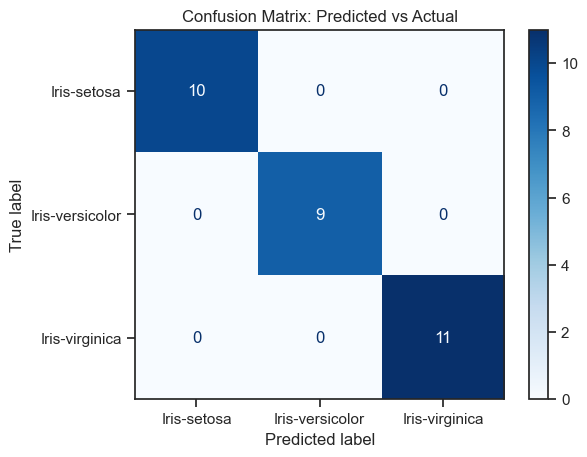

In [38]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
disp.plot(cmap='Blues')
plt.title('Confusion Matrix: Predicted vs Actual')
plt.savefig('confusion_matrix.png')
plt.show()

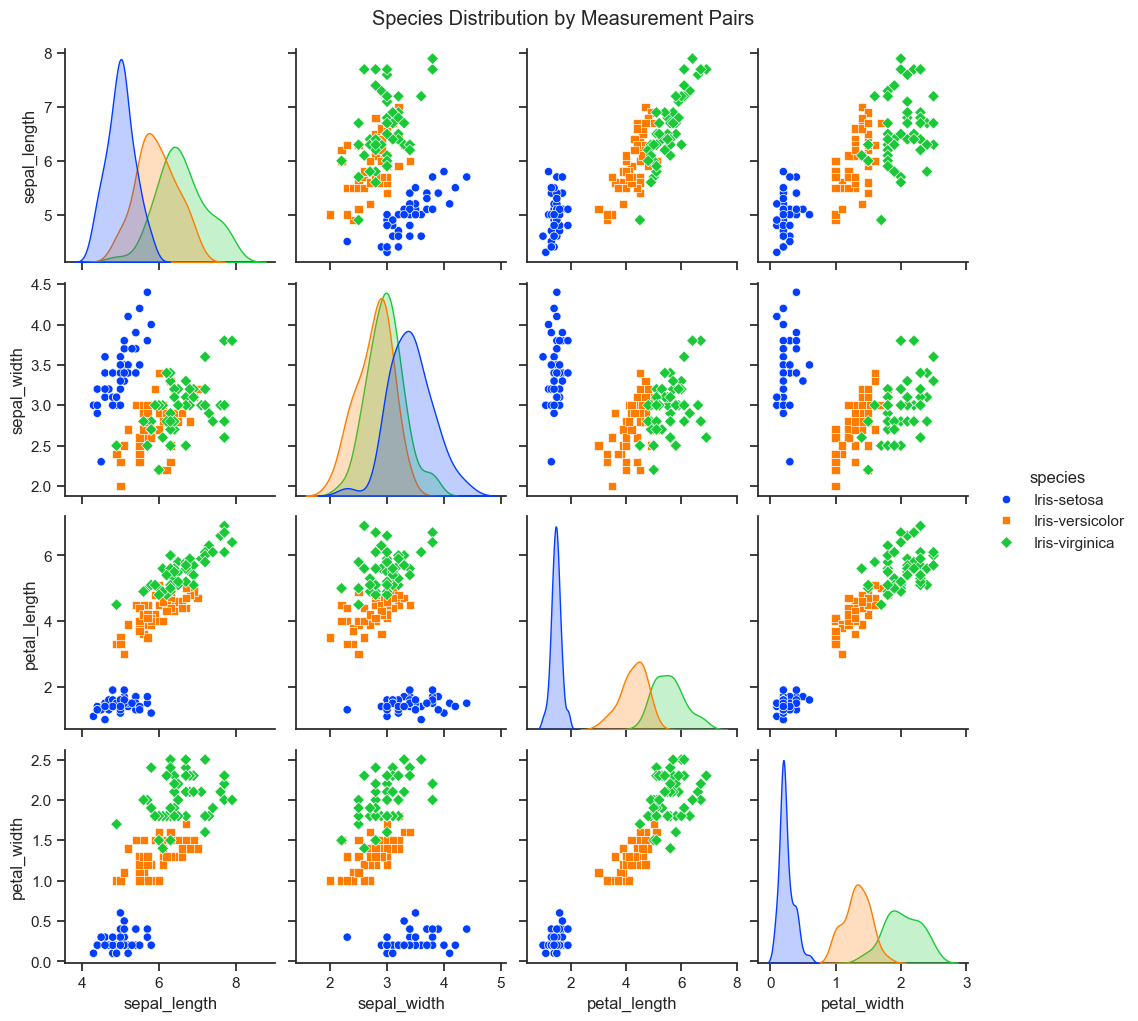

In [39]:
sns.set(style="ticks")
pair_plot = sns.pairplot(df, hue="species", palette="bright", markers=["o", "s", "D"])
pair_plot.fig.suptitle("Species Distribution by Measurement Pairs", y=1.02)
plt.savefig('pair_plot.png')
plt.show()

In [40]:
summary_comparison = df.groupby('species').agg(['mean', 'std']).round(2)
summary_comparison.columns = [f"{col[0]} ({col[1]})" for col in summary_comparison.columns]

print(summary_comparison)

                 sepal_length (mean)  sepal_length (std)  sepal_width (mean)  \
species                                                                        
Iris-setosa                     5.01                0.35                3.42   
Iris-versicolor                 5.94                0.52                2.77   
Iris-virginica                  6.59                0.64                2.97   

                 sepal_width (std)  petal_length (mean)  petal_length (std)  \
species                                                                       
Iris-setosa                   0.38                 1.46                0.17   
Iris-versicolor               0.31                 4.26                0.47   
Iris-virginica                0.32                 5.55                0.55   

                 petal_width (mean)  petal_width (std)  
species                                                 
Iris-setosa                    0.24               0.11  
Iris-versicolor                1

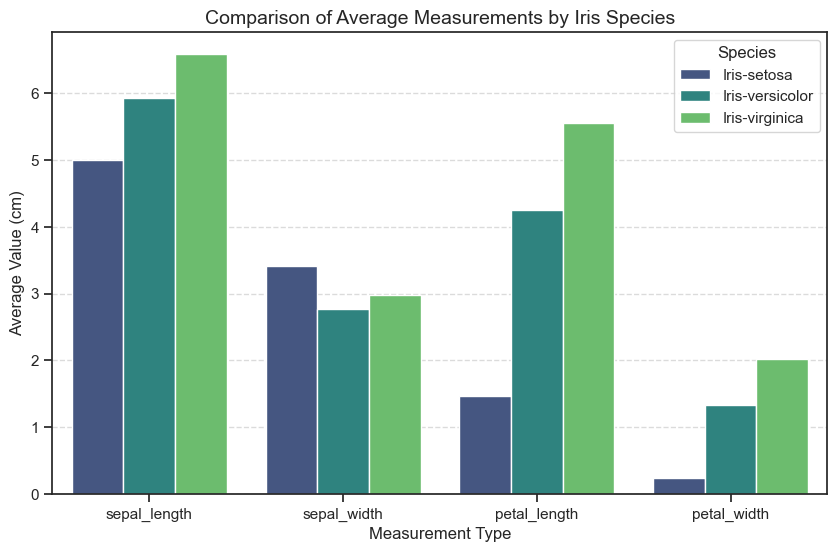

In [41]:
df_means = df.groupby('species').mean().reset_index()
df_melted = df_means.melt(id_vars='species', var_name='Measurement', value_name='Average Value (cm)')

plt.figure(figsize=(10, 6))
sns.barplot(data=df_melted, x='Measurement', y='Average Value (cm)', hue='species', palette='viridis')
plt.title('Comparison of Average Measurements by Iris Species', fontsize=14)
plt.xlabel('Measurement Type', fontsize=12)
plt.ylabel('Average Value (cm)', fontsize=12)
plt.legend(title='Species')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.savefig('iris_bar_comparison.png')
plt.show()

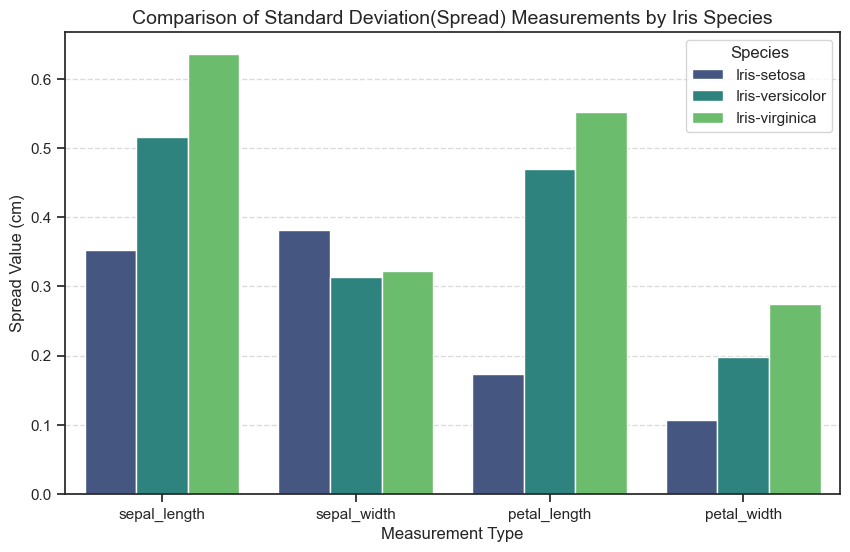

In [42]:
df_std = df.groupby('species').std().reset_index()
df_melted = df_std.melt(id_vars='species', var_name='Measurement', value_name='Spread Value (cm)')

plt.figure(figsize=(10, 6))
sns.barplot(data=df_melted, x='Measurement', y='Spread Value (cm)', hue='species', palette='viridis')
plt.title('Comparison of Standard Deviation(Spread) Measurements by Iris Species', fontsize=14)
plt.xlabel('Measurement Type', fontsize=12)
plt.ylabel('Spread Value (cm)', fontsize=12)
plt.legend(title='Species')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.savefig('iris_bar_comparison_std.png')
plt.show()